### Imports

In [1]:
import random
import warnings
from pathlib import Path

import numpy as np
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.utils.preprocessing_utils import (
    get_waveform_transformer,
    get_spectrogram_transformer,
)

warnings.filterwarnings('ignore', category=UserWarning)

### Constants

In [2]:
DATASET = DatasetType.SHIPSEAR
FILTERBANK = FilterbankType.GAMMATONE

### Visualising ShipsEar audio as Gammatone Spectrograms

STFT kernels created, time used = 0.0142 seconds
STFT filter created, time used = 0.0030 seconds
Gammatone filter created, time used = 0.0030 seconds


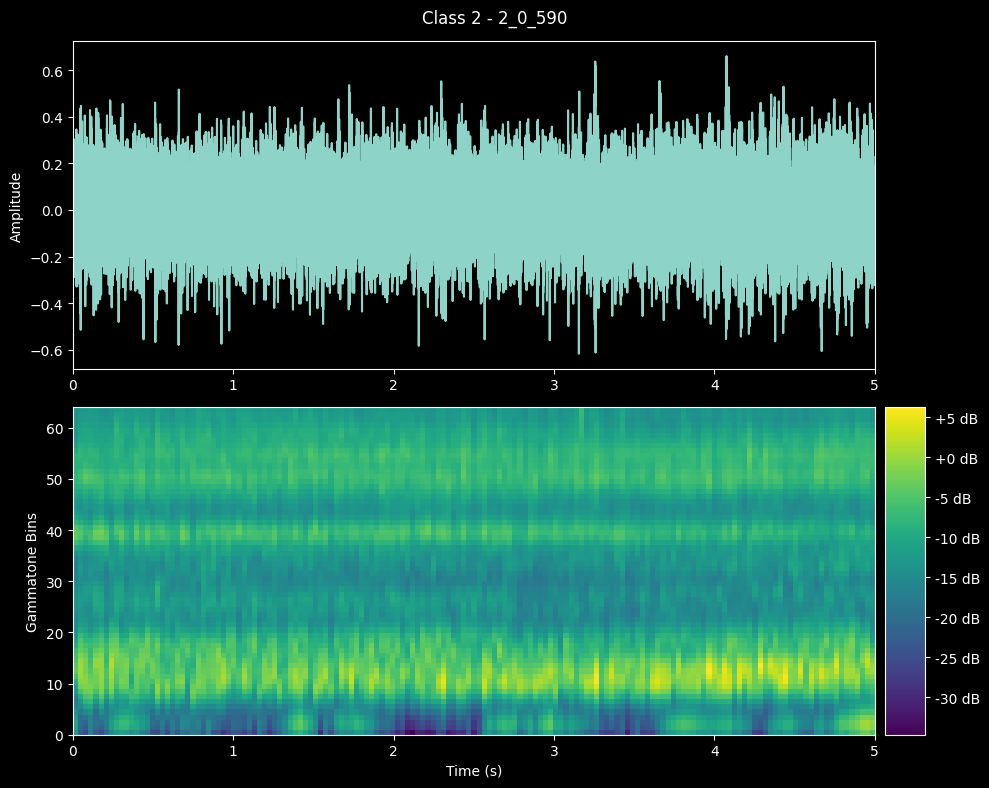

Original: 80000 samples (5.00s)
Preprocessed: 80000 samples (5.00s)


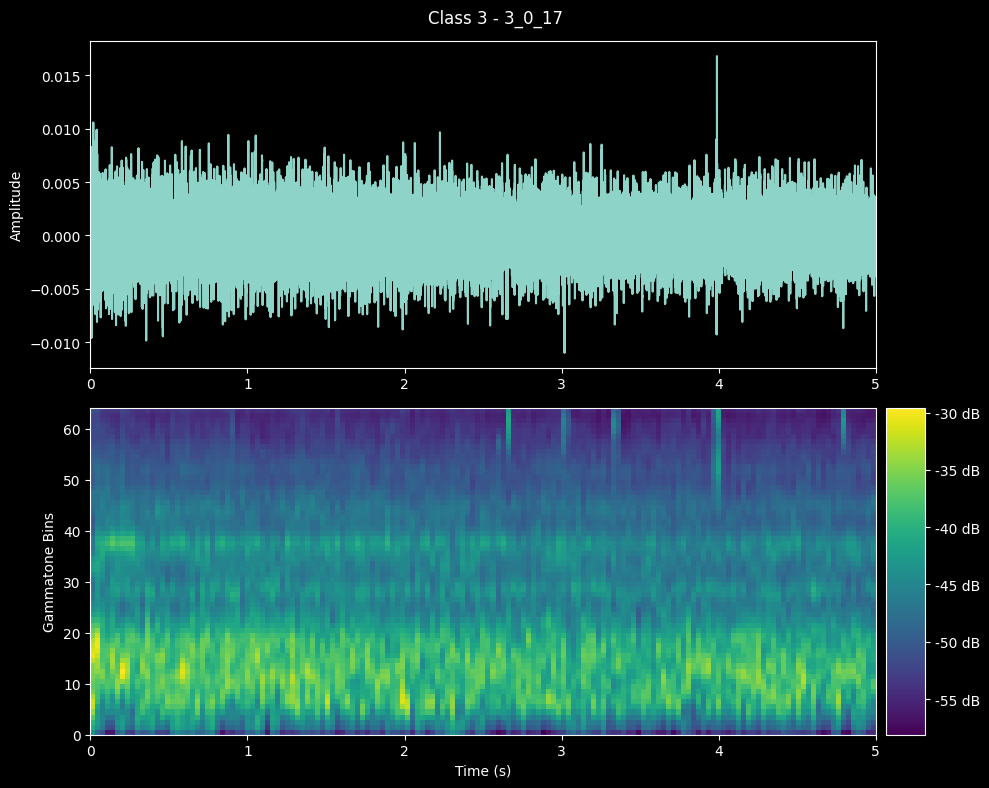

Original: 80000 samples (5.00s)
Preprocessed: 80000 samples (5.00s)


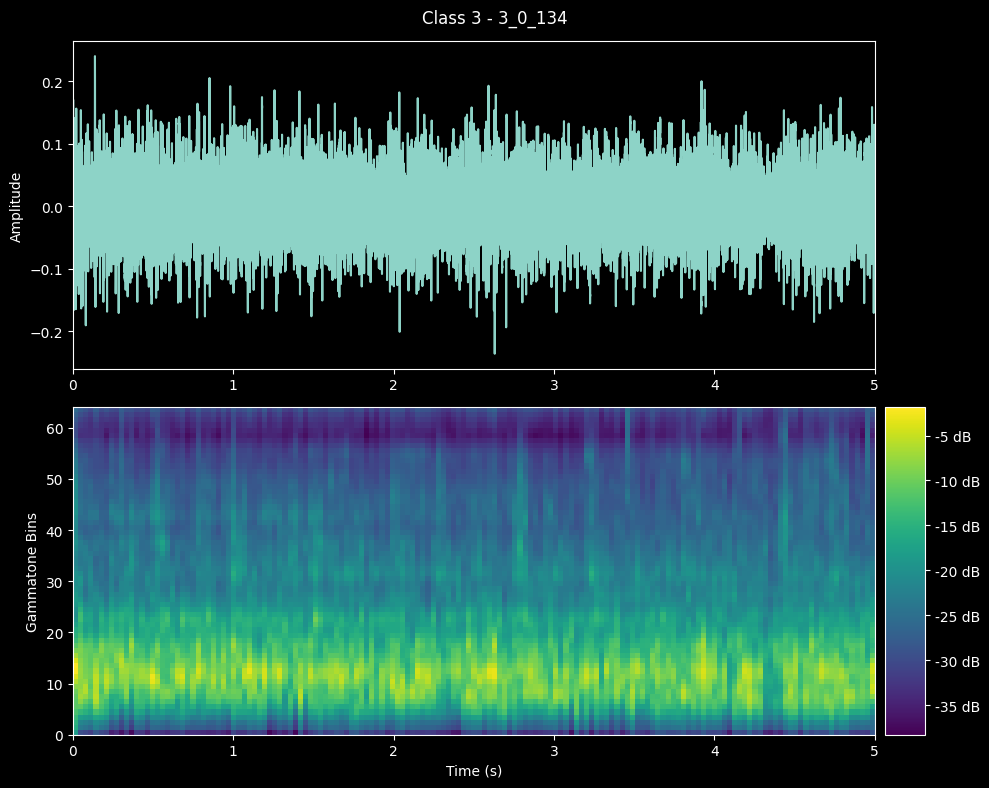

Original: 80000 samples (5.00s)
Preprocessed: 80000 samples (5.00s)


In [3]:
def get_random_audio(dir: Path) -> Path:
    audio_files = list(dir.rglob('*.wav'))
    return random.choice(audio_files)


def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer(DATASET.config)
    spectrogram_transformer = get_spectrogram_transformer(DATASET.config, FILTERBANK)

    for i in range(3):
        audio_path = get_random_audio(DATASET.input_dir)
        label = audio_path.stem.split('_')[0]

        raw_waveform, raw_sample_rate = torchaudio.load(audio_path)
        new_waveform = waveform_transformer(raw_waveform)
        mel_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / DATASET.config.target_sample_rate

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        fig.suptitle(f'Class {label} - {audio_path.stem}')

        # Waveform
        time_axis = np.linspace(0, new_duration, new_samples)
        ax1.plot(time_axis, new_waveform[0].numpy())
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes('right', size='5%', pad=0.1)
        cax1.axis('off')

        # Gammatone Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='viridis',
            extent=[0, new_duration, 0, DATASET.config.n_bins],
        )
        ax2.set_ylabel('Gammatone Bins')
        ax2.set_xlabel('Time (s)')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes('right', size='5%', pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

        display(Audio(data=new_waveform, rate=DATASET.config.target_sample_rate))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1] / raw_sample_rate:.2f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.2f}s)')


visualise_audio_data()